<h1><b>2. Principal Component Analysis of Fruits </b></h1>

2 (a) To extract features from each image in the training data, SIFT (Scale-invariant feature transform) is employed. To make sure SIFT gives us 128 dimensions per image keypoint, the image is first converted to greyscale.

In [1]:
import numpy as np
import cv2 as cv
 
img = cv.imread('Fruit-Subset/Training/Apple Golden 1/0_100.jpg')
gray= cv.cvtColor(img,cv.COLOR_BGR2GRAY)
 
sift = cv.SIFT_create()
kp = sift.detect(gray,None)
 
img=cv.drawKeypoints(gray,kp,img)
 
cv.imwrite('sift_keypoints.jpg',img)

True

The following image results from taking the 128 dimensional keypoints of the first golden apple image.

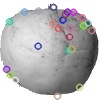

2 (b) A keypoints dataset KP is created below such that it contains all the keypoints from all the training images.

In [2]:
import os

def extract_all_sift_features(image_folder):
    sift = cv.SIFT_create()
    all_features = []
    
    for root, dirs, files in os.walk(image_folder):
        for file in files:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                img_path = os.path.join(root, file)
                img = cv.imread(img_path)
                gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
                kp, des = sift.detectAndCompute(gray, None)
                if des is not None:
                    all_features.append(des)
    
    return all_features

image_folder = 'Fruit-Subset/Training'
features = extract_all_sift_features(image_folder)

In [3]:
features_array = np.vstack(features) #KP: Stack all feature descriptors into a single array
print("Total SIFT features extracted:", features_array.shape[0])
print("Feature dimension:", features_array.shape[1])
print("Sample SIFT feature vector:", features_array[0])

Total SIFT features extracted: 179596
Feature dimension: 128
Sample SIFT feature vector: [  1.   0.   0.   0.   8.  53.  10.   0. 159.  85.   0.   0.  15.  29.
   1.   2. 159. 113.   0.   0.   0.   0.   0.   0.   8.   5.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   3.  39.  37.   4.   0. 159.  31.
   0.   0.  55.  32.   1.   7. 159.  90.   0.   0.   0.   0.   0.  10.
  26.   6.   0.   0.   0.   0.   0.   0.   0.   0.   0.   8.  56.   9.
   0.   0. 125.   3.   0.   2.  32.  19.   5.  67. 159.  12.   0.   0.
   0.   0.   1. 121.  23.   1.   0.   0.   0.   0.   0.   5.   0.   0.
   0.   0.  31.  29.   3.   0. 153.   9.   0.   0.  13.  11.   1.  39.
 159.  20.   0.   0.   0.   0.   0.  45.   2.   0.   0.   0.   0.   0.
   0.   1.]


2 (c) K means clustering such that K = 100 on KP is performed

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=100, random_state=0, n_init="auto").fit(features_array)

# Access results
labels = kmeans.labels_          # Cluster labels for each sample
centers = kmeans.cluster_centers_ # Coordinates of cluster centers

2 (d) The K-mean clusters are then used to construct a 100-D vector for each image such that each of the dimensions corresponds to the number of keypoints with each indexed (0-99) cluster. For an image A, if 20 keypoints exist in cluster 1, 10 keypoints exist in cluster 2, and none exist in other clusters, the vector represent Image A takes on the form:

$v = \left(20,10,0,0,0,...,0,0\right)$

In [5]:
'''
Constructing 100-dimension vector for each image representing the keypoints present in that image
such that the i-th dimension of the vector represents the number of keypoints in that image that belong to the i-th cluster.

Recall that the features_array has 128 dimensions for each keypoint, and the kmeans variable contains the cluster centers 
and labels for each keypoint. We can use the labels to count how many keypoints from each image belong to each cluster to
construct the 100-dimensional vectors.

'''
image_vectors = []  # List to hold the 100-dimensional vectors for each image
for image in features: #Iterate though each row in the features, where each row corresponds to a keypoint descriptor
    #print(image.shape) #This will print the shape of each image keypoint descriptor, which should be (keypoints, 128) since SIFT features are 128-dimensional.
    image_vector = np.zeros(100)  # Initialize a 100-dimensional vector for the image
    cluster_label = kmeans.predict(image)  # Get the cluster label for the keypoints
    #Find the number of keypoints in the image that belong to each cluster and update the image_vector accordingly
    for label in cluster_label:
        image_vector[label] += 1

    image_vectors.append(image_vector)  # Add the image vector to the list
    #print(image_vector.shape)  # This will print the 100-dimensional vector for each image

image_vectors = np.array(image_vectors)  # Convert the list of image vectors to a NumPy array for easier handling

2 (e) Now that we have defined our 100-dimensional dataset D (with image_vectors) we can smoothly proceed to PCA

2 (f) We now reduce the dataset D to 2 dimensions with PCA

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(image_vectors)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [7]:
import os

pca_result = pca.fit_transform(image_vectors)
# Create a list to store the label (folder name) for each image
labels = []
image_folder = 'Fruit-Subset/Training'

# This loop mirrors the SIFT extraction loop perfectly so the order matches
for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.endswith(('.jpg', '.png', '.jpeg')):
            # The folder name is the fruit class (e.g., 'Apple Braeburn')
            class_name = os.path.basename(root)
            labels.append(class_name)

# Sanity check: The number of labels should exactly match the PCA results
print(f"Number of labels: {len(labels)}")
print(f"Number of PCA points: {pca_result.shape[0]}")

Number of labels: 4600
Number of PCA points: 4600


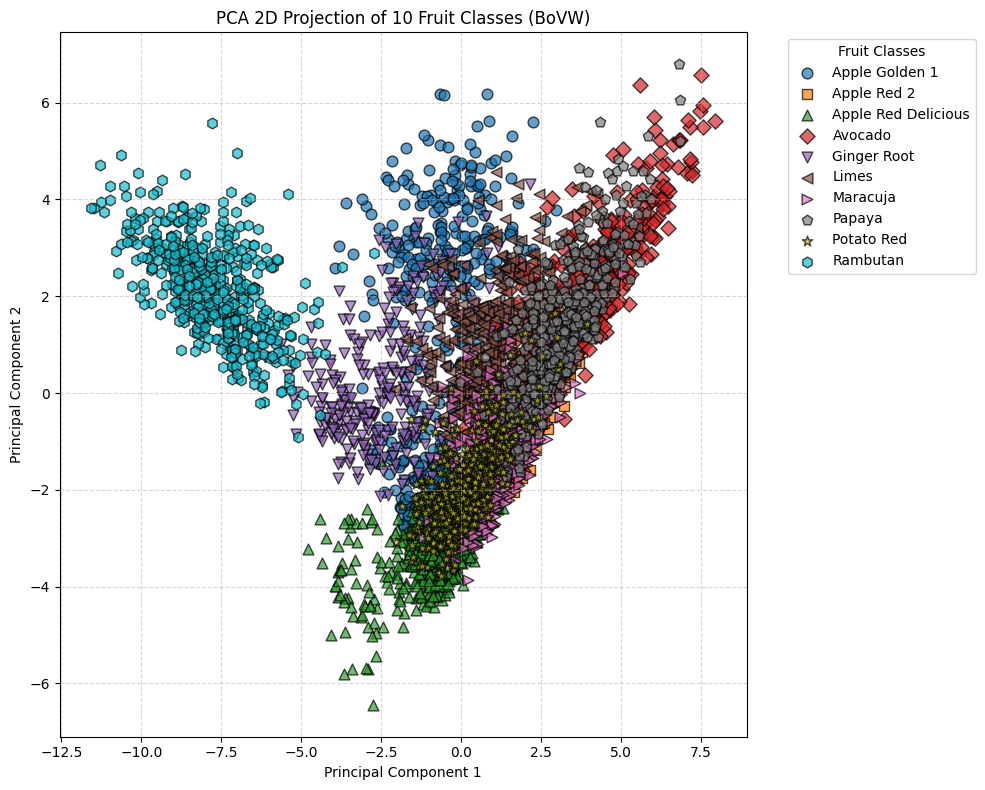

In [8]:
import matplotlib.pyplot as plt

# Convert labels to a numpy array for indexing
labels_array = np.array(labels)

# Get the 10 unique class names
classes = np.unique(labels_array)

# Get a colormap with exactly 10 distinct colors
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h'] # 10 distinct markers for better visibility

plt.figure(figsize=(10, 8))

# Loop through each of the 10 classes
for i, cls in enumerate(classes):
    # Find the row indices in pca_result where the label matches the current class
    idx = np.where(labels_array == cls)[0]
    
    # Scatter plot for this specific fruit class
    plt.scatter(
        pca_result[idx, 0],  # X coordinates
        pca_result[idx, 1],  # Y coordinates
        color=colors[i],     # Assign a unique color
        marker=markers[i],   # Assign a unique symbol
        label=cls,           # Label for the legend
        alpha=0.7,           # Slight transparency to see overlapping points
        edgecolors='k',      # Black border around points
        s=60                 # Size of the points
    )

# Formatting the plot
plt.title('PCA 2D Projection of 10 Fruit Classes (BoVW)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Places the legend outside the plot so it doesn't cover the data
plt.legend(title="Fruit Classes", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout() # Adjusts layout so the legend isn't cut off
plt.show()

It is evident from the above figure that the Rambutan classe is the most separable from the rest of the classes. The Apple Golden 1 class shares common space with the Ginger Root and Limes classes, but not the others. Additionally the Papaya, Potato Red, Apple Red 2, Maracuja, Apple Red Delicious, and Avocado classes significantly overlap and can't be separated. This was an expected result since there are minimal differences between the different types of Apples in greyscale.

<h1><b>3. Support Vector Machines </b></h1>

It is first required that the validation (test) set be built in the same fashion as the training set before proceeding.

In [9]:
image_folder = 'Fruit-Subset/Test'
test_features = extract_all_sift_features(image_folder)
test_vectors = []  # List to hold the 100-dimensional vectors for each image
for image in test_features: #Iterate though each row in the features, where each row corresponds to a keypoint descriptor
    #print(image.shape) #This will print the shape of each image keypoint descriptor, which should be (keypoints, 128) since SIFT features are 128-dimensional.
    image_vector = np.zeros(100)  # Initialize a 100-dimensional vector for the image
    cluster_label = kmeans.predict(image)  # Get the cluster label for the keypoints
    #Find the number of keypoints in the image that belong to each cluster and update the image_vector accordingly
    for label in cluster_label:
        image_vector[label] += 1

    test_vectors.append(image_vector)  # Add the image vector to the list
    #print(image_vector.shape)  # This will print the 100-dimensional vector for each image

test_vectors = np.array(test_vectors)  # Convert the list of image vectors to a NumPy array for easier handling

In [10]:
test_labels = []
image_folder = 'Fruit-Subset/Test'

# This loop mirrors the SIFT extraction loop perfectly so the order matches
for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.endswith(('.jpg', '.png', '.jpeg')):
            # The folder name is the fruit class (e.g., 'Apple Braeburn')
            class_name = os.path.basename(root)
            test_labels.append(class_name)


3 (a) The Linear SVM is constructed like so below

In [11]:
from sklearn.svm import SVC

#Create the SVM classifier with a linear kernel

svc = SVC(kernel='linear')#.fit(image_vectors, labels)

3 (b) Stratified K-fold cross validation with $K = 10$. For 3 (c) and (d), the code is as follows.

In [12]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 2. Define the settings (hyperparameters) to test
param_grid = {'C': [0.01,0.1, 1, 10, 100]}

# 3. Create the Stratified 10-Fold cross-validator
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) #3 (because we have 10 classes, we want to ensure that each fold has a representative sample of each class)

# 4. Perform the model selection
print("Running Stratified 10-Fold CV Model Selection...")
grid_search = GridSearchCV(
    estimator=svc, 
    param_grid=param_grid, 
    cv=skf,                 # Pass the StratifiedKFold object here
    scoring='accuracy',
    return_train_score=True,
)

# 4. "Learn" (train) the model using your 100-D dataset (X_train) and your labels (y_train)
grid_search.fit(image_vectors, labels)

# 5. Output the results
print(f"Best parameter found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_ * 100:.2f}%")

# Now you have your final, optimized prediction model!
best_svm = grid_search.best_estimator_

Running Stratified 10-Fold CV Model Selection...
Best parameter found: {'C': 0.1}
Best cross-validation accuracy: 95.24%


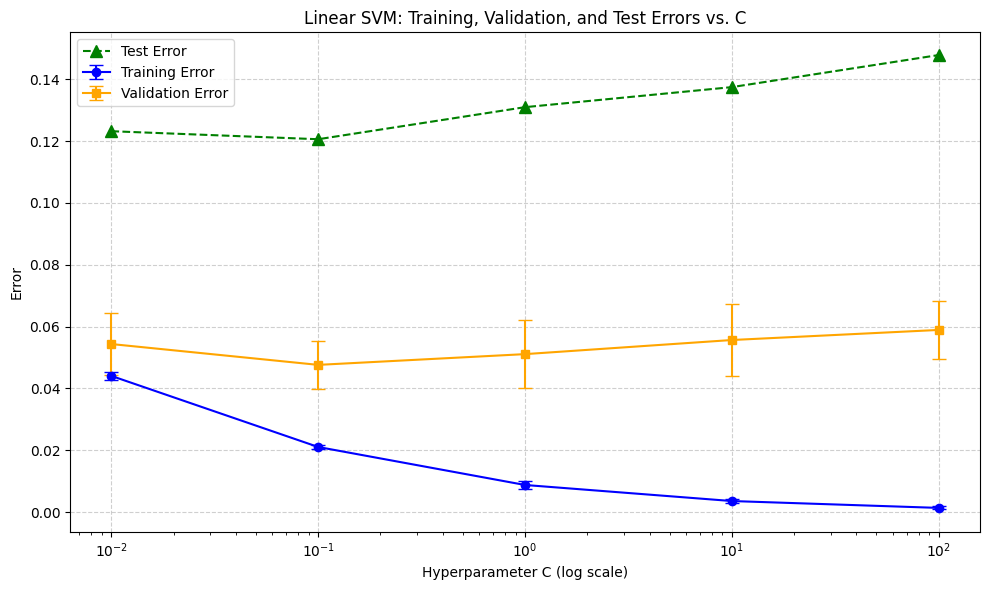

In [13]:
# Extract results
lin_results = grid_search.cv_results_
C_values = np.array(lin_results['param_C'].data, dtype=float)

# Calculate errors (1 - accuracy)
lin_mean_train_error = 1 - lin_results['mean_train_score']
lin_std_train_error = lin_results['std_train_score']

lin_mean_val_error = 1 - lin_results['mean_test_score']
lin_std_val_error = lin_results['std_test_score']

# Calculate test error for each C by training on the full training set
lin_test_errors = []
for c in C_values:
    lin_model = SVC(kernel='linear', C=c)
    lin_model.fit(image_vectors, labels)
    test_acc = lin_model.score(test_vectors, test_labels)
    lin_test_errors.append(1 - test_acc)

# Plotting
plt.figure(figsize=(10, 6))

# Train error with error bars
plt.errorbar(C_values, lin_mean_train_error, yerr=lin_std_train_error, fmt='-o', capsize=5, label='Training Error', color='blue')

# Validation error with error bars
plt.errorbar(C_values, lin_mean_val_error, yerr=lin_std_val_error, fmt='-s', capsize=5, label='Validation Error', color='orange')

# Test error
plt.plot(C_values, lin_test_errors, '--^', color='green', label='Test Error', markersize=8)

plt.xscale('log')
plt.xlabel('Hyperparameter C (log scale)')
plt.ylabel('Error')
plt.title('Linear SVM: Training, Validation, and Test Errors vs. C')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('linear_svm_error_plot.png')

3 (e) Other Kernels 

<h2><b>RBF Kernel</b></h2>

In [14]:
print("Running Stratified 10-Fold CV Model Selection...")
rbf_svc = SVC(kernel='rbf')
grid_search = GridSearchCV(
    estimator=rbf_svc, 
    param_grid=param_grid, 
    cv=skf,                 # Pass the StratifiedKFold object here
    scoring='accuracy',
    return_train_score=True,
)

# 4. "Learn" (train) the model using your 100-D dataset (X_train) and your labels (y_train)
grid_search.fit(image_vectors, labels)

# 5. Output the results
print(f"Best parameter found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_ * 100:.2f}%")

# Now you have your final, optimized prediction model!
best_svm_rbf = grid_search.best_estimator_

Running Stratified 10-Fold CV Model Selection...
Best parameter found: {'C': 10}
Best cross-validation accuracy: 96.93%


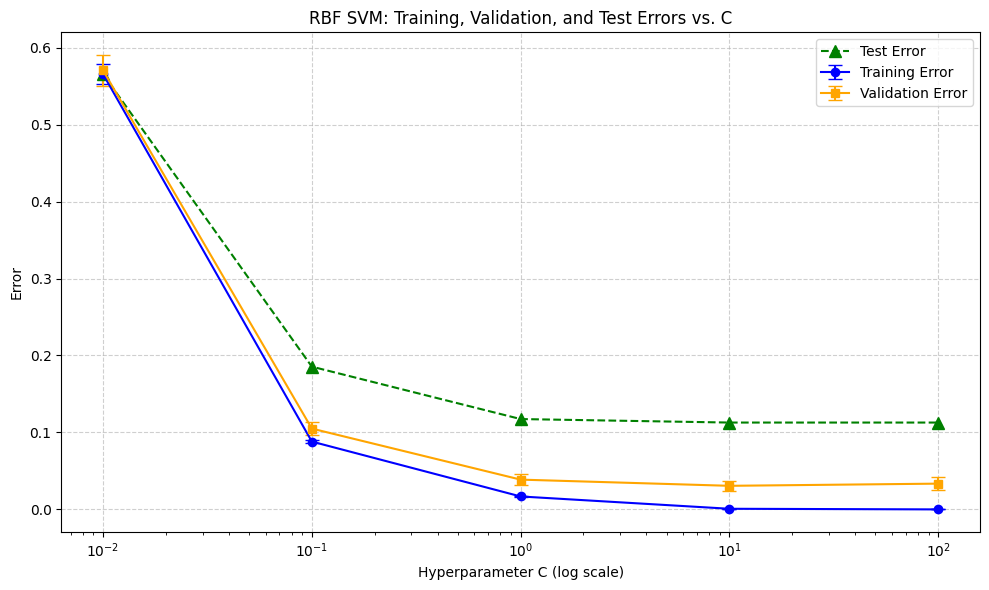

In [15]:
# Extract results
rbf_results = grid_search.cv_results_
C_values = np.array(rbf_results['param_C'].data, dtype=float)

# Calculate errors (1 - accuracy)
rbf_mean_train_error = 1 - rbf_results['mean_train_score']
rbf_std_train_error = rbf_results['std_train_score']

rbf_mean_val_error = 1 - rbf_results['mean_test_score']
rbf_std_val_error = rbf_results['std_test_score']

# Calculate test error for each C by training on the full training set
rbf_test_errors = []
for c in C_values:
    rbf_model = SVC(kernel='rbf', C=c)
    rbf_model.fit(image_vectors, labels)
    test_acc = rbf_model.score(test_vectors, test_labels)
    rbf_test_errors.append(1 - test_acc)

# Plotting
plt.figure(figsize=(10, 6))

# Train error with error bars
plt.errorbar(C_values, rbf_mean_train_error, yerr=rbf_std_train_error, fmt='-o', capsize=5, label='Training Error', color='blue')

# Validation error with error bars
plt.errorbar(C_values, rbf_mean_val_error, yerr=rbf_std_val_error, fmt='-s', capsize=5, label='Validation Error', color='orange')

# Test error
plt.plot(C_values, rbf_test_errors, '--^', color='green', label='Test Error', markersize=8)

plt.xscale('log')
plt.xlabel('Hyperparameter C (log scale)')
plt.ylabel('Error')
plt.title('RBF SVM: Training, Validation, and Test Errors vs. C')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('rbf_svm_error_plot.png')

<h2><b>Poly Kernel</b></h2>

In [16]:
print("Running Stratified 10-Fold CV Model Selection...")
poly_svc = SVC(kernel='poly')
grid_search = GridSearchCV(
    estimator=poly_svc, 
    param_grid=param_grid, 
    cv=skf,                 # Pass the StratifiedKFold object here
    scoring='accuracy',
    return_train_score=True,
)

# 4. "Learn" (train) the model using your 100-D dataset (X_train) and your labels (y_train)
grid_search.fit(image_vectors, labels)

# 5. Output the results
print(f"Best parameter found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_ * 100:.2f}%")

# Now you have your final, optimized prediction model!
best_svm_poly = grid_search.best_estimator_

Running Stratified 10-Fold CV Model Selection...
Best parameter found: {'C': 100}
Best cross-validation accuracy: 93.24%


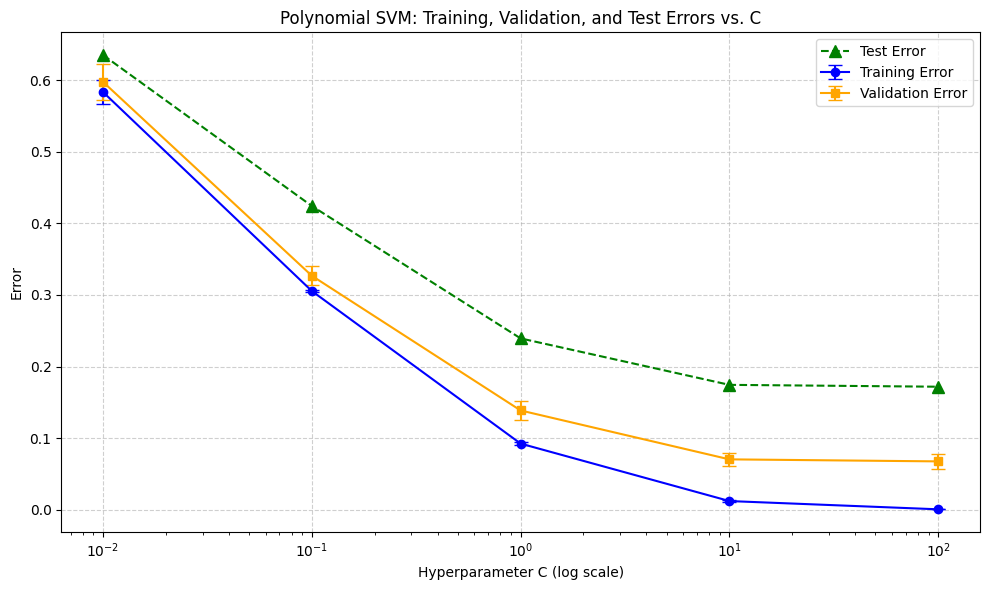

In [17]:
# Extract results
poly_results = grid_search.cv_results_
C_values = np.array(poly_results['param_C'].data, dtype=float)

# Calculate errors (1 - accuracy)
poly_mean_train_error = 1 - poly_results['mean_train_score']
poly_std_train_error = poly_results['std_train_score']

poly_mean_val_error = 1 - poly_results['mean_test_score']
poly_std_val_error = poly_results['std_test_score']

# Calculate test error for each C by training on the full training set
poly_test_errors = []
for c in C_values:
    poly_model = SVC(kernel='poly', C=c)
    poly_model.fit(image_vectors, labels)
    test_acc = poly_model.score(test_vectors, test_labels)
    poly_test_errors.append(1 - test_acc)

# Plotting
plt.figure(figsize=(10, 6))

# Train error with error bars
plt.errorbar(C_values, poly_mean_train_error, yerr=poly_std_train_error, fmt='-o', capsize=5, label='Training Error', color='blue')

# Validation error with error bars
plt.errorbar(C_values, poly_mean_val_error, yerr=poly_std_val_error, fmt='-s', capsize=5, label='Validation Error', color='orange')

# Test error
plt.plot(C_values, poly_test_errors, '--^', color='green', label='Test Error', markersize=8)

plt.xscale('log')
plt.xlabel('Hyperparameter C (log scale)')
plt.ylabel('Error')
plt.title('Polynomial SVM: Training, Validation, and Test Errors vs. C')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('poly_svm_error_plot.png')

<h2><b>Sigmoid Kernel</b></h2>

In [18]:
print("Running Stratified 10-Fold CV Model Selection...")
sig_svc = SVC(kernel='sigmoid')
grid_search = GridSearchCV(
    estimator=sig_svc, 
    param_grid=param_grid, 
    cv=skf,                 # Pass the StratifiedKFold object here
    scoring='accuracy',
    return_train_score=True,
)

# 4. "Learn" (train) the model using your 100-D dataset (X_train) and your labels (y_train)
grid_search.fit(image_vectors, labels)

# 5. Output the results
print(f"Best parameter found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_ * 100:.2f}%")

# Now you have your final, optimized prediction model!
best_svm_sig = grid_search.best_estimator_

Running Stratified 10-Fold CV Model Selection...
Best parameter found: {'C': 0.1}
Best cross-validation accuracy: 84.83%


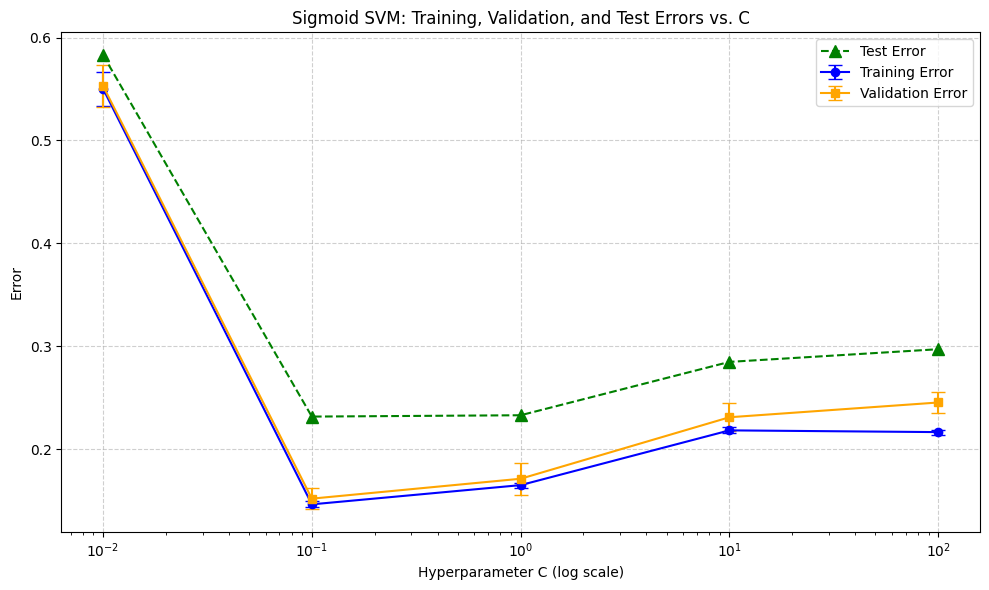

In [19]:
# Extract results
sig_results = grid_search.cv_results_
C_values = np.array(sig_results['param_C'].data, dtype=float)

# Calculate errors (1 - accuracy)
sig_mean_train_error = 1 - sig_results['mean_train_score']
sig_std_train_error = sig_results['std_train_score']

sig_mean_val_error = 1 - sig_results['mean_test_score']
sig_std_val_error = sig_results['std_test_score']

# Calculate test error for each C by training on the full training set
sig_test_errors = []
for c in C_values:
    sig_model = SVC(kernel='sigmoid', C=c)
    sig_model.fit(image_vectors, labels)
    test_acc = sig_model.score(test_vectors, test_labels)
    sig_test_errors.append(1 - test_acc)

# Plotting
plt.figure(figsize=(10, 6))

# Train error with error bars
plt.errorbar(C_values, sig_mean_train_error, yerr=sig_std_train_error, fmt='-o', capsize=5, label='Training Error', color='blue')

# Validation error with error bars
plt.errorbar(C_values, sig_mean_val_error, yerr=sig_std_val_error, fmt='-s', capsize=5, label='Validation Error', color='orange')

# Test error
plt.plot(C_values, sig_test_errors, '--^', color='green', label='Test Error', markersize=8)

plt.xscale('log')
plt.xlabel('Hyperparameter C (log scale)')
plt.ylabel('Error')
plt.title('Sigmoid SVM: Training, Validation, and Test Errors vs. C')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('sigmoid_svm_error_plot.png')

3 (f) Comparison of different kernels shown below.

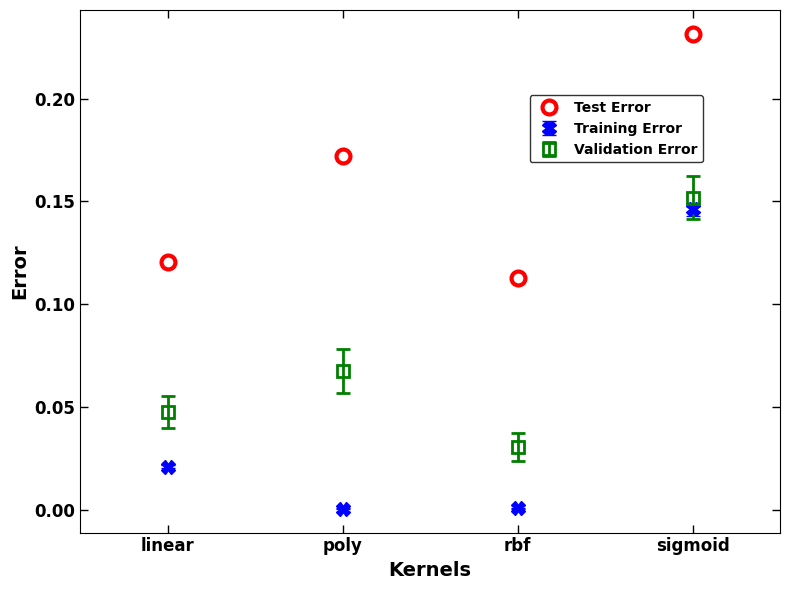

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define prefixes to match the exact order in your screenshot
prefixes = ['lin', 'poly', 'rbf', 'sig']
kernel_names = ['linear', 'poly', 'rbf', 'sigmoid']

best_train = []
best_train_std = []
best_val = []
best_val_std = []
best_test = []

# 2. Extract best performance dynamically
for prefix in prefixes:
    test_err  = eval(f"{prefix}_test_errors")
    val_err   = eval(f"{prefix}_mean_val_error")
    train_err = eval(f"{prefix}_mean_train_error")
    val_std   = eval(f"{prefix}_std_val_error")
    train_std = eval(f"{prefix}_std_train_error")
    
    # Find the index that minimizes TEST error
    best_idx = np.argmin(test_err)
    
    best_test.append(test_err[best_idx])
    best_val.append(val_err[best_idx])
    best_train.append(train_err[best_idx])
    best_val_std.append(val_std[best_idx])
    best_train_std.append(train_std[best_idx])

# 3. Setup the categorical scatter plot
plt.figure(figsize=(8, 6))
x = np.arange(len(kernel_names))

# Plot Training Error (Blue filled 'X' with error bars)
plt.errorbar(x, best_train, yerr=best_train_std, fmt='X', color='blue', 
             label='Training Error', capsize=5, elinewidth=2, 
             markersize=10, linestyle='None')

# Plot Validation Error (Adding this per your request - Green hollow squares)
plt.errorbar(x, best_val, yerr=best_val_std, fmt='s', color='green', 
             label='Validation Error', capsize=5, elinewidth=2, markersize=8, 
             markerfacecolor='none', markeredgewidth=2, linestyle='None')

# Plot Test Error (Red hollow circles, no error bars, matching the image)
plt.plot(x, best_test, marker='o', color='red', label='Test Error', 
         linestyle='None', markersize=10, markerfacecolor='none', markeredgewidth=3)

# 4. MATLAB-style Formatting
plt.ylabel('Error', fontsize=14, fontweight='bold')
plt.xlabel('Kernels', fontsize=14, fontweight='bold')

# Set categorical X-ticks
plt.xticks(x, kernel_names, fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# Add padding to the X-axis so markers don't sit directly on the frame edges
plt.xlim(-0.5, 3.5)

# Recreate the boxed legend from the image, pushing it inside the plot area
plt.legend(loc='upper right', bbox_to_anchor=(0.9, 0.85), 
           frameon=True, edgecolor='black', prop={'weight': 'bold'})

# Mimic the inward-pointing tick marks on all 4 sides of the plot
plt.tick_params(direction='in', top=True, right=True, length=6, width=1)

# Display the plot
plt.tight_layout()
plt.show()

3 (g) For linear, polynomial, radial basis function, and sigmoid kernels, the SVM model had lower training and validation errors relative to the test set. Only the sigmoid kernel had a training error within the validation error bar. There was no such kernel were the test error fall within the error bar of the validation error.

3 (h) The best C values to minimize the mean error for each kernel was:

In [23]:
prefixes = ['lin', 'poly', 'rbf', 'sig']
kernel_names = ['Linear', 'Polynomial', 'RBF', 'Sigmoid']

for prefix, name in zip(prefixes, kernel_names):
    # Grab the test error array for this kernel
    test_err = eval(f"{prefix}_test_errors")
    
    # Find the index of the lowest error
    best_idx = np.argmin(test_err)
    
    # Print the C value located at that winning index
    print(f"Best C value for {name} Kernel: {C_values[best_idx]}")

Best C value for Linear Kernel: 0.1
Best C value for Polynomial Kernel: 100.0
Best C value for RBF Kernel: 10.0
Best C value for Sigmoid Kernel: 0.1


3(h), continued: The radial basis function kernel attained the best overall classification performance relative to the other kernels.

<h1><b>4. Deep Learning - Training a Simple Convolution Neural Network Model (CNN)</b></h1>

4 (a) K-fold with $K=10$

In [3]:
import os
import numpy as np
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = 'Fruit-Subset/Training'

filepaths = []
labels = []

# Loop through the directory to get paths and class names
for class_name in os.listdir(train_dir):
    class_dir = os.path.join(train_dir, class_name)
    if os.path.isdir(class_dir):
        for file in os.listdir(class_dir):
            if file.endswith(('.jpg', '.jpeg', '.png')):
                filepaths.append(os.path.join(class_dir, file))
                labels.append(class_name) # String label for stratification

filepaths = np.array(filepaths)
labels = np.array(labels)

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 1. Create a function that returns a fresh, un-trained CNN
def build_fresh_cnn():
    model = Sequential([
        Conv2D(8, (3, 3), activation='relu', input_shape=(100, 100, 3)),
        Conv2D(8, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(16, activation='relu'),
        Dense(16, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
import pandas as pd

# 2. Setup the Stratified 10-Fold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# We will use an ImageDataGenerator to load the images on the fly and normalize them
datagen = ImageDataGenerator(rescale=1./255)

fold_accuracies = []
all_fold_train_acc = []
all_fold_val_acc = []
# 3. Loop through the 10 folds
for fold_num, (train_idx, val_idx) in enumerate(skf.split(filepaths, labels), 1):
    print(f"\n--- Training Fold {fold_num} ---")
    
    # Slice the filepaths and labels for this specific fold
    train_paths, val_paths = filepaths[train_idx], filepaths[val_idx]
    train_labels, val_labels = labels[train_idx], labels[val_idx]
    
    # Put them into temporary Pandas DataFrames (which ImageDataGenerator loves)
    train_df = pd.DataFrame({'filename': train_paths, 'class': train_labels})
    val_df = pd.DataFrame({'filename': val_paths, 'class': val_labels})
    
    # Create the training generator
    train_gen = datagen.flow_from_dataframe(
        train_df, x_col='filename', y_col='class',
        target_size=(100, 100), batch_size=32, class_mode='categorical', shuffle=True
    )
    
    # Create the validation generator
    val_gen = datagen.flow_from_dataframe(
        val_df, x_col='filename', y_col='class',
        target_size=(100, 100), batch_size=32, class_mode='categorical', shuffle=False
    )
    
    # Get a brand new, blank CNN
    model = build_fresh_cnn()
    
    # Train for 20 epochs on this specific fold
    history = model.fit(train_gen, validation_data=val_gen, epochs=20, verbose=0)
    
    all_fold_train_acc.append(history.history['accuracy'])
    all_fold_val_acc.append(history.history['val_accuracy'])

    # Record the final validation accuracy for this fold
    final_val_acc = history.history['val_accuracy'][-1]
    print(f"Fold {fold_num} Validation Accuracy: {final_val_acc * 100:.2f}%")
    fold_accuracies.append(final_val_acc)

# 4. Calculate final performance
train_acc_array = np.array(all_fold_train_acc)
val_acc_array = np.array(all_fold_val_acc)
print(f"\nOverall 10-Fold Cross-Validation Accuracy: {np.mean(fold_accuracies) * 100:.2f}%")


--- Training Fold 1 ---
Found 4140 validated image filenames belonging to 10 classes.
Found 460 validated image filenames belonging to 10 classes.


c:\Users\Shark\Fruit-Dataset\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 Validation Accuracy: 100.00%

--- Training Fold 2 ---
Found 4140 validated image filenames belonging to 10 classes.
Found 460 validated image filenames belonging to 10 classes.


c:\Users\Shark\Fruit-Dataset\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 Validation Accuracy: 90.65%

--- Training Fold 3 ---
Found 4140 validated image filenames belonging to 10 classes.
Found 460 validated image filenames belonging to 10 classes.


c:\Users\Shark\Fruit-Dataset\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 3 Validation Accuracy: 95.87%

--- Training Fold 4 ---
Found 4140 validated image filenames belonging to 10 classes.
Found 460 validated image filenames belonging to 10 classes.


c:\Users\Shark\Fruit-Dataset\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4 Validation Accuracy: 100.00%

--- Training Fold 5 ---
Found 4140 validated image filenames belonging to 10 classes.
Found 460 validated image filenames belonging to 10 classes.


c:\Users\Shark\Fruit-Dataset\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5 Validation Accuracy: 100.00%

--- Training Fold 6 ---
Found 4140 validated image filenames belonging to 10 classes.
Found 460 validated image filenames belonging to 10 classes.


c:\Users\Shark\Fruit-Dataset\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 6 Validation Accuracy: 100.00%

--- Training Fold 7 ---
Found 4140 validated image filenames belonging to 10 classes.
Found 460 validated image filenames belonging to 10 classes.


c:\Users\Shark\Fruit-Dataset\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 7 Validation Accuracy: 99.78%

--- Training Fold 8 ---
Found 4140 validated image filenames belonging to 10 classes.
Found 460 validated image filenames belonging to 10 classes.


c:\Users\Shark\Fruit-Dataset\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 8 Validation Accuracy: 100.00%

--- Training Fold 9 ---
Found 4140 validated image filenames belonging to 10 classes.
Found 460 validated image filenames belonging to 10 classes.


c:\Users\Shark\Fruit-Dataset\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 9 Validation Accuracy: 88.04%

--- Training Fold 10 ---
Found 4140 validated image filenames belonging to 10 classes.
Found 460 validated image filenames belonging to 10 classes.


c:\Users\Shark\Fruit-Dataset\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 10 Validation Accuracy: 10.65%

Overall 10-Fold Cross-Validation Accuracy: 88.50%


4 (b) Plot is shown below.

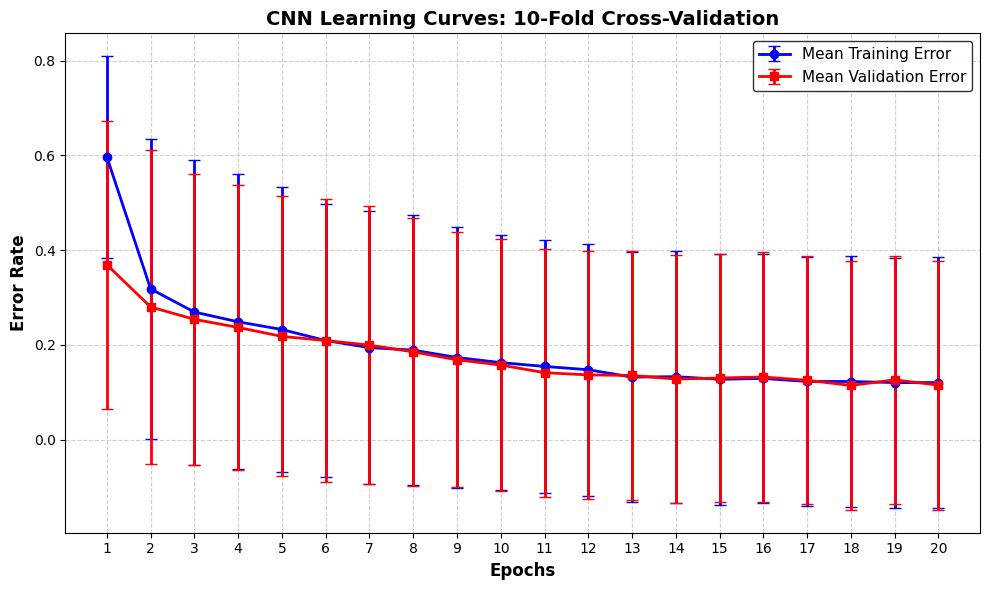

In [31]:
import matplotlib.pyplot as plt

# 1. Convert Accuracy to Error Rate
train_err_array = 1.0 - train_acc_array
val_err_array = 1.0 - val_acc_array

# 2. Calculate the Mean Error across the 10 folds for each epoch
mean_train_err = np.mean(train_err_array, axis=0)
mean_val_err = np.mean(val_err_array, axis=0)

# 3. Calculate the Standard Deviation (for the error bars) across the 10 folds
std_train_err = np.std(train_err_array, axis=0)
std_val_err = np.std(val_err_array, axis=0)

# 4. Create the Epochs X-axis (1 to 20)
epochs = np.arange(1, 21)

# 5. Plot the Learning Curves
plt.figure(figsize=(10, 6))

# Training Error Curve (Blue circles)
plt.errorbar(epochs, mean_train_err, yerr=std_train_err, 
             fmt='-o', color='blue', ecolor='blue', capsize=4, 
             label='Mean Training Error', linewidth=2, markersize=6)

# Validation Error Curve (Red squares)
plt.errorbar(epochs, mean_val_err, yerr=std_val_err, 
             fmt='-s', color='red', ecolor='red', capsize=4, 
             label='Mean Validation Error', linewidth=2, markersize=6)

# 6. Academic Formatting
plt.title('CNN Learning Curves: 10-Fold Cross-Validation', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Error Rate', fontsize=12, fontweight='bold')

# Ensure the x-axis shows every single epoch number neatly
plt.xticks(epochs)

# Add Legend and Grid
plt.legend(loc='upper right', frameon=True, edgecolor='black', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

4 (c) The epoch were the validation error is at its minimum value is the 18th epoch.

In [4]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Put ALL your training filepaths and labels into a single DataFrame
# (No more splitting into train/val subsets!)
train_df = pd.DataFrame({'filename': filepaths, 'class': labels})

# 2. Setup the ImageDataGenerator
datagen = ImageDataGenerator(rescale=1./255)

# 3. Create a single training generator using the entire training dataset
train_gen = datagen.flow_from_dataframe(
    train_df, 
    x_col='filename', 
    y_col='class',
    target_size=(100, 100), 
    batch_size=32, 
    class_mode='categorical', 
    shuffle=True
)

# 4. Get a brand new, blank CNN
final_model = build_fresh_cnn()

# 5. Train for exactly 18 epochs on all the data
print("Training final CNN on 100% of training data for 18 epochs...")

# Notice we removed 'validation_data' and changed verbose to 1 so you can watch the progress
history = final_model.fit(
    train_gen, 
    epochs=18, 
    verbose=1 
)

print("\nFinal training complete! The model is ready to be evaluated on the unseen Test set.")

Found 4600 validated image filenames belonging to 10 classes.
Training final CNN on 100% of training data for 18 epochs...


c:\Users\Shark\Fruit-Dataset\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/18
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7624 - loss: 0.7321
Epoch 2/18
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9976 - loss: 0.0194
Epoch 3/18
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0016
Epoch 4/18
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 7.1283e-04
Epoch 5/18
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 4.2532e-04
Epoch 6/18
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 2.9736e-04
Epoch 7/18
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 2.2113e-04
Epoch 8/18
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 1.7198e-04
Epoch 9/18
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 1.3653e-04
Epoch 10/18
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 1.0641e-04
Epoch 11/18
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 8.8166e-05
Epoch 12/1

In [6]:
import os
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_dir = 'Fruit-Subset/Test'

test_filepaths = []
test_labels = []

# Loop through the TEST directory
for class_name in os.listdir(test_dir):
    class_dir = os.path.join(test_dir, class_name)
    if os.path.isdir(class_dir):
        for file in os.listdir(class_dir):
            if file.endswith(('.jpg', '.jpeg', '.png')):
                test_filepaths.append(os.path.join(class_dir, file))
                test_labels.append(class_name) 

test_filepaths = np.array(test_filepaths)
test_labels = np.array(test_labels)

# 1. Put the paths into a Pandas DataFrame
test_df = pd.DataFrame({'filename': test_filepaths, 'class': test_labels})

# 2. Setup the Test ImageDataGenerator
# IMPORTANT: You MUST rescale the test pixels by 1./255, exactly as you did for training!
test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Create the Test Generator
test_gen = test_datagen.flow_from_dataframe(
    test_df, 
    x_col='filename', 
    y_col='class',
    target_size=(100, 100), # Must match the size you used in training
    batch_size=32, 
    class_mode='categorical', 
    shuffle=False           # Keep false to match predictions to images.
)

# 4. Evaluate the model
print("\nEvaluating model on the Test Set...")
test_loss, test_accuracy = final_model.evaluate(test_gen, verbose=1)

print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Error Rate: {(1 - test_accuracy) * 100:.2f}%")

Found 1542 validated image filenames belonging to 10 classes.

Evaluating model on the Test Set...
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9974 - loss: 0.0060

Final Test Loss: 0.0060
Final Test Accuracy: 99.74%
Final Test Error Rate: 0.26%


The test error was a mere 0.26 %. The mechanism by which the CNN attained this accuracy was likely due to the color feature of the fruits being utilized, unlike the SVMs that used SIFT, which required greyscale.

4 (d) The performance is far superior to that of the best of the SVM models (Radial Basis Function).

<h1><b>5. Transfer Learning Via Feature Extraction</b></h1>

5 (a) The pretrained Alexnet model is evaluated on the test set as shown below.

In [10]:
import torch
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader

# 1. AlexNet requires very specific image preprocessing
# It was trained on 224x224 images and normalized with specific ImageNet statistics
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load the Test dataset using PyTorch's ImageFolder (similar to Keras's directory tool)
test_dir = 'Fruit-Subset/Test'
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 3. Load the pre-trained AlexNet
model = models.alexnet(pretrained=True)

# Output to 10 classes, 
# model.classifier[6] = torch.nn.Linear(model.classifier[6].in_features, 10)

# 4. Set the model to Evaluation mode (disables dropout layers, etc.)
model.eval()

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

correct = 0
total = 0

print("Evaluating Test Set with pre-trained AlexNet...")

# 5. Run the evaluation loop (no_grad saves memory since we aren't training)
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        
        # Get the prediction (the highest probability out of the 1000 classes)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# 6. Calculate final accuracy
test_accuracy = 100 * correct / total
print(f"AlexNet Test Accuracy: {test_accuracy:.2f}%")

Evaluating Test Set with pre-trained AlexNet...
AlexNet Test Accuracy: 0.00%


The test accuracy is 0 %

5 (b) When freezing the layers and leaving the last layer for training for 20 epochs, the following results:

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models


train_dir = 'Fruit-Subset/Training'
test_dir = 'Fruit-Subset/Test'

train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 1. Load the pre-trained AlexNet
print("Loading pre-trained AlexNet...")
model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)

# 2. FREEZE ALL LAYERS
# By setting requires_grad = False, we tell PyTorch NOT to update these 
# weights during the training process (backward pass).
for param in model.parameters():
    param.requires_grad = False

# 3. MODIFY THE LAST LAYER
# AlexNet's classifier is a sequence of layers. The very last one (index 6) 
# is a Linear layer that outputs 1000 classes. We need to replace it.
# First, find out how many input features that last layer expects (it's 4096).
num_features = model.classifier[6].in_features

# Replace the 6th layer with a brand new one that outputs 10 classes.
# By default, new layers in PyTorch automatically have requires_grad=True!
model.classifier[6] = nn.Linear(num_features, 10)

# Print the modified classifier to verify the change
print("\nModified AlexNet Classifier:")
print(model.classifier)

# 4. PREPARE FOR TRAINING
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Optimizer
# CRITICAL: We only pass the parameters of the newly created layer to the optimizer!
optimizer = optim.Adam(model.classifier[6].parameters(), lr=0.001)

# 5. THE TRAINING LOOP (20 Epochs)
epochs = 20

print(f"\nStarting training on {device} for {epochs} epochs...")


epochs = 20

# Create lists to store the error at each epoch
train_errors = []
val_errors = []

print(f"Starting training and validation for {epochs} epochs...")

for epoch in range(epochs):
    # ==========================
    # 1. TRAINING PHASE
    # ==========================
    model.train()  # Put model in training mode
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    # Calculate Training Error (1 - Accuracy) for this epoch
    train_err = 1.0 - (correct_train / total_train)
    train_errors.append(train_err)
    
    # ==========================
    # 2. VALIDATION (TEST) PHASE
    # ==========================
    model.eval()  # Put model in evaluation mode (disables dropout, etc.)
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # Don't track gradients to save memory and speed
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    # Calculate Validation Error (1 - Accuracy) using the Test Set
    val_err = 1.0 - (correct_val / total_val)
    val_errors.append(val_err)
    
    # Print progress
    print(f"Epoch [{epoch+1}/{epochs}] - Train Error: {train_err:.4f} | Val (Test) Error: {val_err:.4f}")

Loading pre-trained AlexNet...

Modified AlexNet Classifier:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=4096, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=4096, out_features=10, bias=True)
)

Starting training on cuda for 20 epochs...
Starting training and validation for 20 epochs...
Epoch [1/20] - Train Error: 0.0228 | Val (Test) Error: 0.0000
Epoch [2/20] - Train Error: 0.0004 | Val (Test) Error: 0.0000
Epoch [3/20] - Train Error: 0.0007 | Val (Test) Error: 0.0000
Epoch [4/20] - Train Error: 0.0007 | Val (Test) Error: 0.0000
Epoch [5/20] - Train Error: 0.0000 | Val (Test) Error: 0.0000
Epoch [6/20] - Train Error: 0.0000 | Val (Test) Error: 0.0000
Epoch [7/20] - Train Error: 0.0000 | Val (Test) Error: 0.0000
Epoch [8/20] - Train Error: 0.0000 | Val (Test) Error: 0.0000
Epoch [9/20] - Train Erro

5 (c) The learning curves for the training and validation (test set) errors are as below.

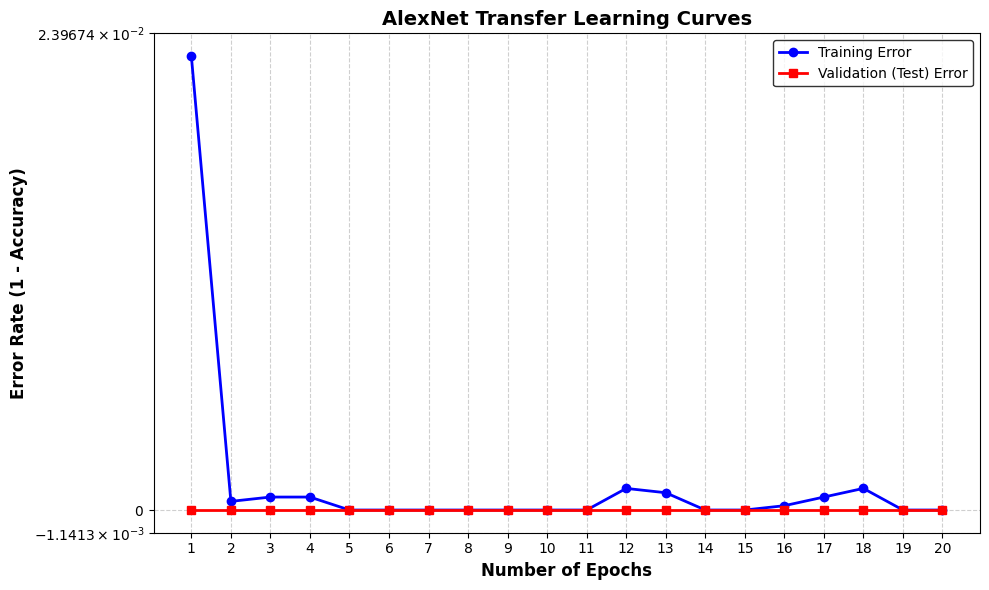

In [19]:
import matplotlib.pyplot as plt

# 1. Set up the X-axis (Epochs 1 through 20)
epoch_list = range(1, epochs + 1)

plt.figure(figsize=(10, 6))

plt.yscale('symlog',base=10)  # Use logarithmic scale for better visibility of error rates

# 2. Plot Training Error (Blue line with circular markers)
plt.plot(epoch_list, train_errors, marker='o', color='blue', 
         linewidth=2, label='Training Error')

# 3. Plot Validation/Test Error (Red line with square markers)
plt.plot(epoch_list, val_errors, marker='s', color='red', 
         linewidth=2, label='Validation (Test) Error')

# 4. Formatting to make it look clean and academic
plt.title('AlexNet Transfer Learning Curves', fontsize=14, fontweight='bold')
plt.xlabel('Number of Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Error Rate (1 - Accuracy)', fontsize=12, fontweight='bold')

# Ensure the x-axis ticks show every integer epoch
plt.xticks(epoch_list)

plt.legend(loc='upper right', frameon=True, edgecolor='black')
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()

The best possible test error in this case is 0 %.

5 (d) Feature extraction is performed with Torchvision.

In [20]:
import torch
import numpy as np
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from torchvision.models.feature_extraction import create_feature_extractor

# 1. Image Preprocessing (Standard AlexNet Requirements)
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load Datasets
# shuffle=False is critical here 

train_dataset = datasets.ImageFolder(root='Fruit-Subset/Training', transform=transform)
test_dataset = datasets.ImageFolder(root='Fruit-Subset/Test', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 3. Load the Pre-trained AlexNet
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT).to(device)
base_model.eval() # Set to evaluation mode

# 4. Setup the TorchVision Feature Extractor
# By inspecting PyTorch's AlexNet architecture, the very last Convolutional 
# layer inside the feature block is named 'features.10'.
return_nodes = {
    'features.10': 'last_conv'  # We map this layer to a friendly name
}

extractor = create_feature_extractor(base_model, return_nodes=return_nodes)

# 5. Define the Extraction Function
def extract_dataset_features(dataloader, model_extractor, device):
    all_features = []
    all_labels = []
    
    with torch.no_grad(): 
        for images, labels in dataloader:
            images = images.to(device)
            
            
            outputs = model_extractor(images)
            
            # Extract the raw 4D tensor from our designated layer
            # Shape is (Batch_Size, 256_Channels, 13_Height, 13_Width)
            conv_features = outputs['last_conv']
            
            # Flatten the 4D tensor into a 2D array (Batch_Size, Total_Features)
            # This is required so standard models like SVMs can read the data!
            flat_features = torch.flatten(conv_features, start_dim=1)
            
            all_features.append(flat_features.cpu().numpy())
            all_labels.append(labels.numpy())
            
    # Stack the list of batches into one giant NumPy array
    return np.vstack(all_features), np.concatenate(all_labels)

# 6. Run the Extraction
print(f"Extracting features using device: {device}...")

print("Processing Training Set...")
X_train_features, y_train_labels = extract_dataset_features(train_loader, extractor, device)

print("Processing Test Set...")
X_test_features, y_test_labels = extract_dataset_features(test_loader, extractor, device)

print("\n--- Feature Extraction Complete! ---")
print(f"Training Features Shape: {X_train_features.shape}")
print(f"Test Features Shape:     {X_test_features.shape}")

Extracting features using device: cuda...
Processing Training Set...
Processing Test Set...

--- Feature Extraction Complete! ---
Training Features Shape: (4600, 43264)
Test Features Shape:     (1542, 43264)


5 (e) SVM training is as follows below.

In [21]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the SVM 
# We specify the RBF kernel and set C=10. 
# Adding random_state ensures results are reproducible.
print("Training SVM with RBF kernel and C=10...")
svm_model = SVC(kernel='rbf', C=10, random_state=42)

# 2. Train the SVM using the AlexNet training features
svm_model.fit(X_train_features, y_train_labels)

print("SVM Training Complete!")

# 3. Evaluate the model using the AlexNet test features
print("\nEvaluating SVM on Test Features...")
y_test_pred = svm_model.predict(X_test_features)

# 4. Calculate final accuracy
test_accuracy = accuracy_score(y_test_labels, y_test_pred)
print(f"SVM Test Accuracy: {test_accuracy * 100:.2f}%")

# Print a detailed breakdown of how it performed on each specific fruit
print("\nClassification Report:")
print(classification_report(y_test_labels, y_test_pred))

Training SVM with RBF kernel and C=10...
SVM Training Complete!

Evaluating SVM on Test Features...
SVM Test Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       160
           1       1.00      1.00      1.00       164
           2       1.00      1.00      1.00       166
           3       1.00      1.00      1.00       143
           4       1.00      1.00      1.00        99
           5       1.00      1.00      1.00       166
           6       1.00      1.00      1.00       166
           7       1.00      1.00      1.00       164
           8       1.00      1.00      1.00       150
           9       1.00      1.00      1.00       164

    accuracy                           1.00      1542
   macro avg       1.00      1.00      1.00      1542
weighted avg       1.00      1.00      1.00      1542



In [22]:
# 1. Have the model predict the labels for the training set
print("Evaluating SVM on Training Features...")
y_train_pred = svm_model.predict(X_train_features)

# 2. Calculate the accuracy by comparing predictions to the real labels
train_accuracy = accuracy_score(y_train_labels, y_train_pred)

# 3. Print the result
print(f"SVM Training Accuracy: {train_accuracy * 100:.2f}%")

Evaluating SVM on Training Features...
SVM Training Accuracy: 100.00%


The training error is 0 % and the test error is 0 %.

<h1><b>6. Transfer Learning via Fine-Tuning: Training AlexNet Using a PreTrained AlexNet Model as the starting point</b></h1>

<h1><b>7. Conclusions</b></h1>